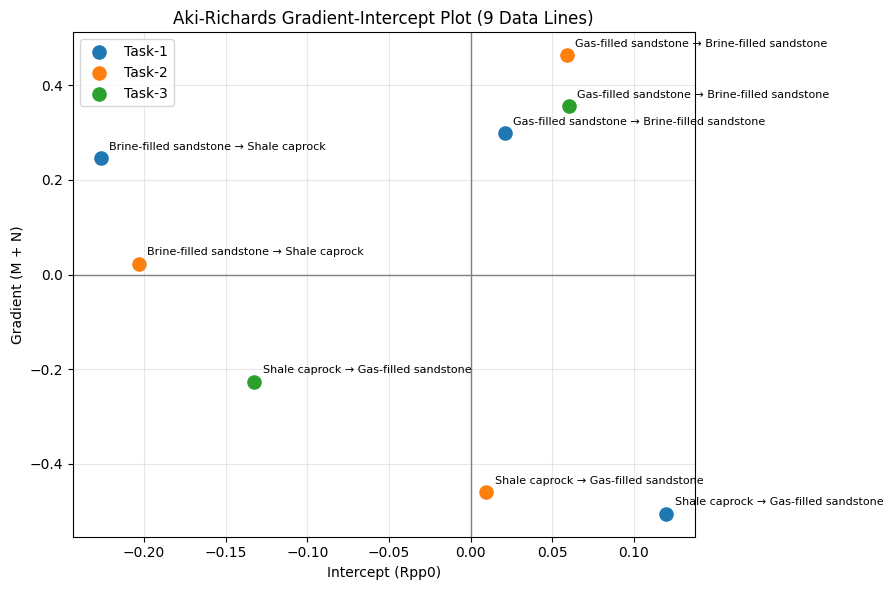

,Task,Rock_Properties,Task_next,Rock_Properties_next,Rpp_0deg,Rpp_10deg,Rpp_20deg,Rpp_30deg,Rpp_40deg
0,Task-1,Shale caprock,Task-1,Gas-filled sandstone,0.120000,0.104861,0.062695,0.003556,-0.054066
1,Task-1,Gas-filled sandstone,Task-1,Brine-filled sandstone,0.020833,0.029859,0.055847,0.095663,0.144505
2,Task-1,Brine-filled sandstone,Task-2,Shale caprock,-0.226319,-0.219072,-0.200384,-0.180120,-0.178116
3,Task-2,Shale caprock,Task-2,Gas-filled sandstone,0.009687,-0.004129,-0.043099,-0.099685,-0.160578
4,Task-2,Gas-filled sandstone,Task-2,Brine-filled sandstone,0.058824,0.072807,0.113071,0.174759,0.250430
5,Task-2,Brine-filled sandstone,Task-3,Shale caprock,-0.203043,-0.202508,-0.203106,-0.212232,-0.245851
6,Task-3,Shale caprock,Task-3,Gas-filled sandstone,-0.132388,-0.139290,-0.160156,-0.195931,-0.250213
7,Task-3,Gas-filled sandstone,Task-3,Brine-filled sandstone,0.060241,0.070979,0.101900,0.149273,0.207384
8,Task-3,Brine-filled sandstone,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def aki_richards(theta_deg, vp1, vp2, vs1, vs2, rho1, rho2):
    """Aki-Richards PP reflectivity (from rockphypy AVO source)."""
    theta = np.deg2rad(theta_deg)

    delta_rho = rho2 - rho1
    delta_vp = vp2 - vp1
    delta_vs = vs2 - vs1

    rho_mean = 0.5 * (rho1 + rho2)
    vp_mean = 0.5 * (vp1 + vp2)
    vs_mean = 0.5 * (vs1 + vs2)

    rpp0 = 0.5 * (delta_rho / rho_mean + delta_vp / vp_mean)
    m = -2 * (vs_mean / vp_mean) ** 2 * (2 * delta_vs / vs_mean + delta_rho / rho_mean)
    n = 0.5 * (delta_vp / vp_mean)

    rpp = rpp0 + m * np.sin(theta) ** 2 + n * np.tan(theta) ** 2
    return rpp


def aki_intercept_gradient(vp1, vp2, vs1, vs2, rho1, rho2):
    """Return Aki-Richards intercept (Rpp0) and gradient (M+N)."""
    delta_rho = rho2 - rho1
    delta_vp = vp2 - vp1
    delta_vs = vs2 - vs1

    rho_mean = 0.5 * (rho1 + rho2)
    vp_mean = 0.5 * (vp1 + vp2)
    vs_mean = 0.5 * (vs1 + vs2)

    rpp0 = 0.5 * (delta_rho / rho_mean + delta_vp / vp_mean)
    m = -2 * (vs_mean / vp_mean) ** 2 * (2 * delta_vs / vs_mean + delta_rho / rho_mean)
    n = 0.5 * (delta_vp / vp_mean)
    gradient = m + n
    return rpp0, gradient


# Use ONLY the 9 lines provided by the assignment
rows = [
    ["Task-1", "Shale caprock", 3300, 1700, 2.35],
    ["Task-1", "Gas-filled sandstone", 4200, 2700, 2.35],
    ["Task-1", "Brine-filled sandstone", 4200, 2100, 2.45],
    ["Task-2", "Shale caprock", 2896, 1402, 2.25],
    ["Task-2", "Gas-filled sandstone", 3322, 2215, 2.00],
    ["Task-2", "Brine-filled sandstone", 3322, 1401, 2.25],
    ["Task-3", "Shale caprock", 2307, 1108, 2.15],
    ["Task-3", "Gas-filled sandstone", 1951, 1301, 1.95],
    ["Task-3", "Brine-filled sandstone", 1951, 930, 2.20],
]

columns = ["Task", "Rock_Properties", "Vp_m_s", "Vs_m_s", "Density_g_cc"]
df = pd.DataFrame(rows, columns=columns)

# Build lower-layer columns using the next line in this 9-line table
for col in ["Vp_m_s", "Vs_m_s", "Density_g_cc", "Rock_Properties", "Task"]:
    df[f"{col}_next"] = df[col].shift(-1)

# Compute Aki-Richards for each line against the next line
# (last line has no lower layer -> NaN)
angles = [0, 10, 20, 30, 40]
valid = df["Vp_m_s_next"].notna()

for ang in angles:
    df[f"Rpp_{ang}deg"] = np.nan
    df.loc[valid, f"Rpp_{ang}deg"] = aki_richards(
        ang,
        df.loc[valid, "Vp_m_s"],
        df.loc[valid, "Vp_m_s_next"],
        df.loc[valid, "Vs_m_s"],
        df.loc[valid, "Vs_m_s_next"],
        df.loc[valid, "Density_g_cc"],
        df.loc[valid, "Density_g_cc_next"],
    )

# Build table output
result = df[
    [
        "Task",
        "Rock_Properties",
        "Task_next",
        "Rock_Properties_next",
        "Rpp_0deg",
        "Rpp_10deg",
        "Rpp_20deg",
        "Rpp_30deg",
        "Rpp_40deg",
    ]
]

# Intercept-gradient values for each interface
plot_df = df.loc[valid, ["Task", "Rock_Properties", "Rock_Properties_next"]].copy()
plot_df["Intercept"], plot_df["Gradient"] = aki_intercept_gradient(
    df.loc[valid, "Vp_m_s"],
    df.loc[valid, "Vp_m_s_next"],
    df.loc[valid, "Vs_m_s"],
    df.loc[valid, "Vs_m_s_next"],
    df.loc[valid, "Density_g_cc"],
    df.loc[valid, "Density_g_cc_next"],
)
plot_df["Interface"] = plot_df["Rock_Properties"] + " → " + plot_df["Rock_Properties_next"]

# Gradient-Intercept crossplot
plt.figure(figsize=(9, 6))
for task, grp in plot_df.groupby("Task"):
    plt.scatter(grp["Intercept"], grp["Gradient"], s=90, label=task)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["Interface"],
        (row["Intercept"], row["Gradient"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
    )

plt.axhline(0, color="gray", lw=1)
plt.axvline(0, color="gray", lw=1)
plt.xlabel("Intercept (Rpp0)")
plt.ylabel("Gradient (M + N)")
plt.title("Aki-Richards Gradient-Intercept Plot (9 Data Lines)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

result

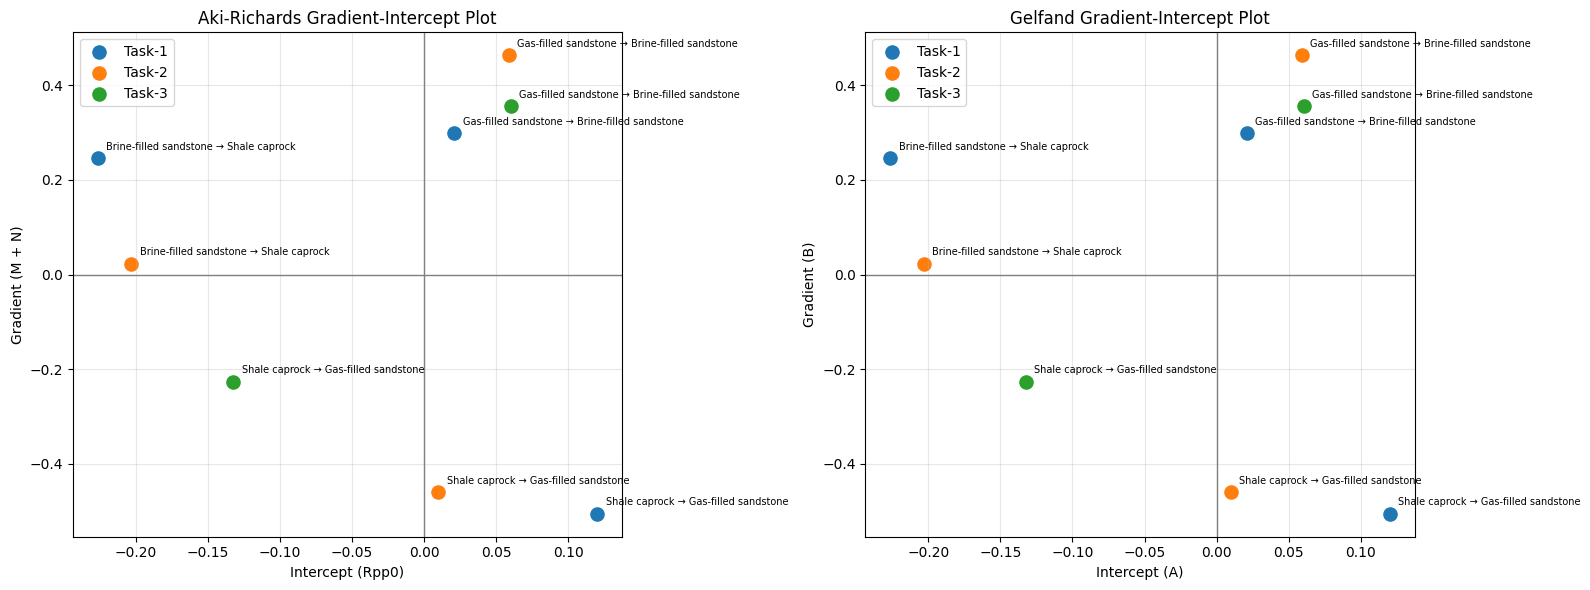

,Task,Interface,AkiRichards_Intercept,AkiRichards_Gradient,Gelfand_Intercept,Gelfand_Gradient
0,Task-1,Shale caprock → Gas-filled sandstone,0.120000,-0.505778,0.120000,-0.505778
1,Task-1,Gas-filled sandstone → Brine-filled sandstone,0.020833,0.299320,0.020833,0.299320
2,Task-1,Brine-filled sandstone → Shale caprock,-0.226319,0.246051,-0.226319,0.246051
3,Task-2,Shale caprock → Gas-filled sandstone,0.009687,-0.460326,0.009687,-0.460326
4,Task-2,Gas-filled sandstone → Brine-filled sandstone,0.058824,0.463741,0.058824,0.463741
5,Task-2,Brine-filled sandstone → Shale caprock,-0.203043,0.023353,-0.203043,0.023353
6,Task-3,Shale caprock → Gas-filled sandstone,-0.132388,-0.226303,-0.132388,-0.226303
7,Task-3,Gas-filled sandstone → Brine-filled sandstone,0.060241,0.356127,0.060241,0.356127


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def aki_richards(theta_deg, vp1, vp2, vs1, vs2, rho1, rho2):
    """Aki-Richards PP reflectivity (from rockphypy AVO source)."""
    theta = np.deg2rad(theta_deg)

    delta_rho = rho2 - rho1
    delta_vp = vp2 - vp1
    delta_vs = vs2 - vs1

    rho_mean = 0.5 * (rho1 + rho2)
    vp_mean = 0.5 * (vp1 + vp2)
    vs_mean = 0.5 * (vs1 + vs2)

    rpp0 = 0.5 * (delta_rho / rho_mean + delta_vp / vp_mean)
    m = -2 * (vs_mean / vp_mean) ** 2 * (2 * delta_vs / vs_mean + delta_rho / rho_mean)
    n = 0.5 * (delta_vp / vp_mean)

    rpp = rpp0 + m * np.sin(theta) ** 2 + n * np.tan(theta) ** 2
    return rpp


def aki_intercept_gradient(vp1, vp2, vs1, vs2, rho1, rho2):
    """Return Aki-Richards intercept (Rpp0) and gradient (M+N)."""
    delta_rho = rho2 - rho1
    delta_vp = vp2 - vp1
    delta_vs = vs2 - vs1

    rho_mean = 0.5 * (rho1 + rho2)
    vp_mean = 0.5 * (vp1 + vp2)
    vs_mean = 0.5 * (vs1 + vs2)

    rpp0 = 0.5 * (delta_rho / rho_mean + delta_vp / vp_mean)
    m = -2 * (vs_mean / vp_mean) ** 2 * (2 * delta_vs / vs_mean + delta_rho / rho_mean)
    n = 0.5 * (delta_vp / vp_mean)
    gradient = m + n
    return rpp0, gradient


def gelfand(theta_deg, vp1, vp2, vs1, vs2, rho1, rho2):
    """Gelfand two-term AVO approximation: Rpp(θ) = A + B*sin²(θ)"""
    theta = np.deg2rad(theta_deg)

    delta_rho = rho2 - rho1
    delta_vp = vp2 - vp1
    delta_vs = vs2 - vs1

    rho_mean = 0.5 * (rho1 + rho2)
    vp_mean = 0.5 * (vp1 + vp2)
    vs_mean = 0.5 * (vs1 + vs2)

    A = 0.5 * (delta_vp / vp_mean + delta_rho / rho_mean)
    B = 0.5 * (delta_vp / vp_mean) - 2 * (vs_mean / vp_mean) ** 2 * (
        2 * delta_vs / vs_mean + delta_rho / rho_mean
    )

    rpp = A + B * np.sin(theta) ** 2
    return rpp


def gelfand_intercept_gradient(vp1, vp2, vs1, vs2, rho1, rho2):
    """Return Gelfand intercept (A) and gradient (B)."""
    delta_rho = rho2 - rho1
    delta_vp = vp2 - vp1
    delta_vs = vs2 - vs1

    rho_mean = 0.5 * (rho1 + rho2)
    vp_mean = 0.5 * (vp1 + vp2)
    vs_mean = 0.5 * (vs1 + vs2)

    A = 0.5 * (delta_vp / vp_mean + delta_rho / rho_mean)
    B = 0.5 * (delta_vp / vp_mean) - 2 * (vs_mean / vp_mean) ** 2 * (
        2 * delta_vs / vs_mean + delta_rho / rho_mean
    )
    return A, B


# Use ONLY the 9 lines provided by the assignment
rows = [
    ["Task-1", "Shale caprock", 3300, 1700, 2.35],
    ["Task-1", "Gas-filled sandstone", 4200, 2700, 2.35],
    ["Task-1", "Brine-filled sandstone", 4200, 2100, 2.45],
    ["Task-2", "Shale caprock", 2896, 1402, 2.25],
    ["Task-2", "Gas-filled sandstone", 3322, 2215, 2.00],
    ["Task-2", "Brine-filled sandstone", 3322, 1401, 2.25],
    ["Task-3", "Shale caprock", 2307, 1108, 2.15],
    ["Task-3", "Gas-filled sandstone", 1951, 1301, 1.95],
    ["Task-3", "Brine-filled sandstone", 1951, 930, 2.20],
]

columns = ["Task", "Rock_Properties", "Vp_m_s", "Vs_m_s", "Density_g_cc"]
df = pd.DataFrame(rows, columns=columns)

# Build lower-layer columns using the next line in this 9-line table
for col in ["Vp_m_s", "Vs_m_s", "Density_g_cc", "Rock_Properties", "Task"]:
    df[f"{col}_next"] = df[col].shift(-1)

# Compute both Aki-Richards and Gelfand for each line against the next line
angles = [0, 10, 20, 30, 40]
valid = df["Vp_m_s_next"].notna()

for ang in angles:
    df[f"Rpp_AkiRichards_{ang}deg"] = np.nan
    df[f"Rpp_Gelfand_{ang}deg"] = np.nan
    
    df.loc[valid, f"Rpp_AkiRichards_{ang}deg"] = aki_richards(
        ang,
        df.loc[valid, "Vp_m_s"],
        df.loc[valid, "Vp_m_s_next"],
        df.loc[valid, "Vs_m_s"],
        df.loc[valid, "Vs_m_s_next"],
        df.loc[valid, "Density_g_cc"],
        df.loc[valid, "Density_g_cc_next"],
    )
    
    df.loc[valid, f"Rpp_Gelfand_{ang}deg"] = gelfand(
        ang,
        df.loc[valid, "Vp_m_s"],
        df.loc[valid, "Vp_m_s_next"],
        df.loc[valid, "Vs_m_s"],
        df.loc[valid, "Vs_m_s_next"],
        df.loc[valid, "Density_g_cc"],
        df.loc[valid, "Density_g_cc_next"],
    )

# Compute intercept-gradient for both methods
plot_df = df.loc[valid, ["Task", "Rock_Properties", "Rock_Properties_next"]].copy()

plot_df["AkiRichards_Intercept"], plot_df["AkiRichards_Gradient"] = aki_intercept_gradient(
    df.loc[valid, "Vp_m_s"],
    df.loc[valid, "Vp_m_s_next"],
    df.loc[valid, "Vs_m_s"],
    df.loc[valid, "Vs_m_s_next"],
    df.loc[valid, "Density_g_cc"],
    df.loc[valid, "Density_g_cc_next"],
)

plot_df["Gelfand_Intercept"], plot_df["Gelfand_Gradient"] = gelfand_intercept_gradient(
    df.loc[valid, "Vp_m_s"],
    df.loc[valid, "Vp_m_s_next"],
    df.loc[valid, "Vs_m_s"],
    df.loc[valid, "Vs_m_s_next"],
    df.loc[valid, "Density_g_cc"],
    df.loc[valid, "Density_g_cc_next"],
)

plot_df["Interface"] = plot_df["Rock_Properties"] + " → " + plot_df["Rock_Properties_next"]

# Create comparison plot: Aki-Richards vs Gelfand
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Aki-Richards Gradient-Intercept
ax = axes[0]
for task, grp in plot_df.groupby("Task"):
    ax.scatter(grp["AkiRichards_Intercept"], grp["AkiRichards_Gradient"], s=90, label=task)

for _, row in plot_df.iterrows():
    ax.annotate(
        row["Interface"],
        (row["AkiRichards_Intercept"], row["AkiRichards_Gradient"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=7,
    )

ax.axhline(0, color="gray", lw=1)
ax.axvline(0, color="gray", lw=1)
ax.set_xlabel("Intercept (Rpp0)")
ax.set_ylabel("Gradient (M + N)")
ax.set_title("Aki-Richards Gradient-Intercept Plot")
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Gelfand Gradient-Intercept
ax = axes[1]
for task, grp in plot_df.groupby("Task"):
    ax.scatter(grp["Gelfand_Intercept"], grp["Gelfand_Gradient"], s=90, label=task)

for _, row in plot_df.iterrows():
    ax.annotate(
        row["Interface"],
        (row["Gelfand_Intercept"], row["Gelfand_Gradient"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=7,
    )

ax.axhline(0, color="gray", lw=1)
ax.axvline(0, color="gray", lw=1)
ax.set_xlabel("Intercept (A)")
ax.set_ylabel("Gradient (B)")
ax.set_title("Gelfand Gradient-Intercept Plot")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Display comparison table
comparison = plot_df[
    [
        "Task",
        "Interface",
        "AkiRichards_Intercept",
        "AkiRichards_Gradient",
        "Gelfand_Intercept",
        "Gelfand_Gradient",
    ]
]
comparison

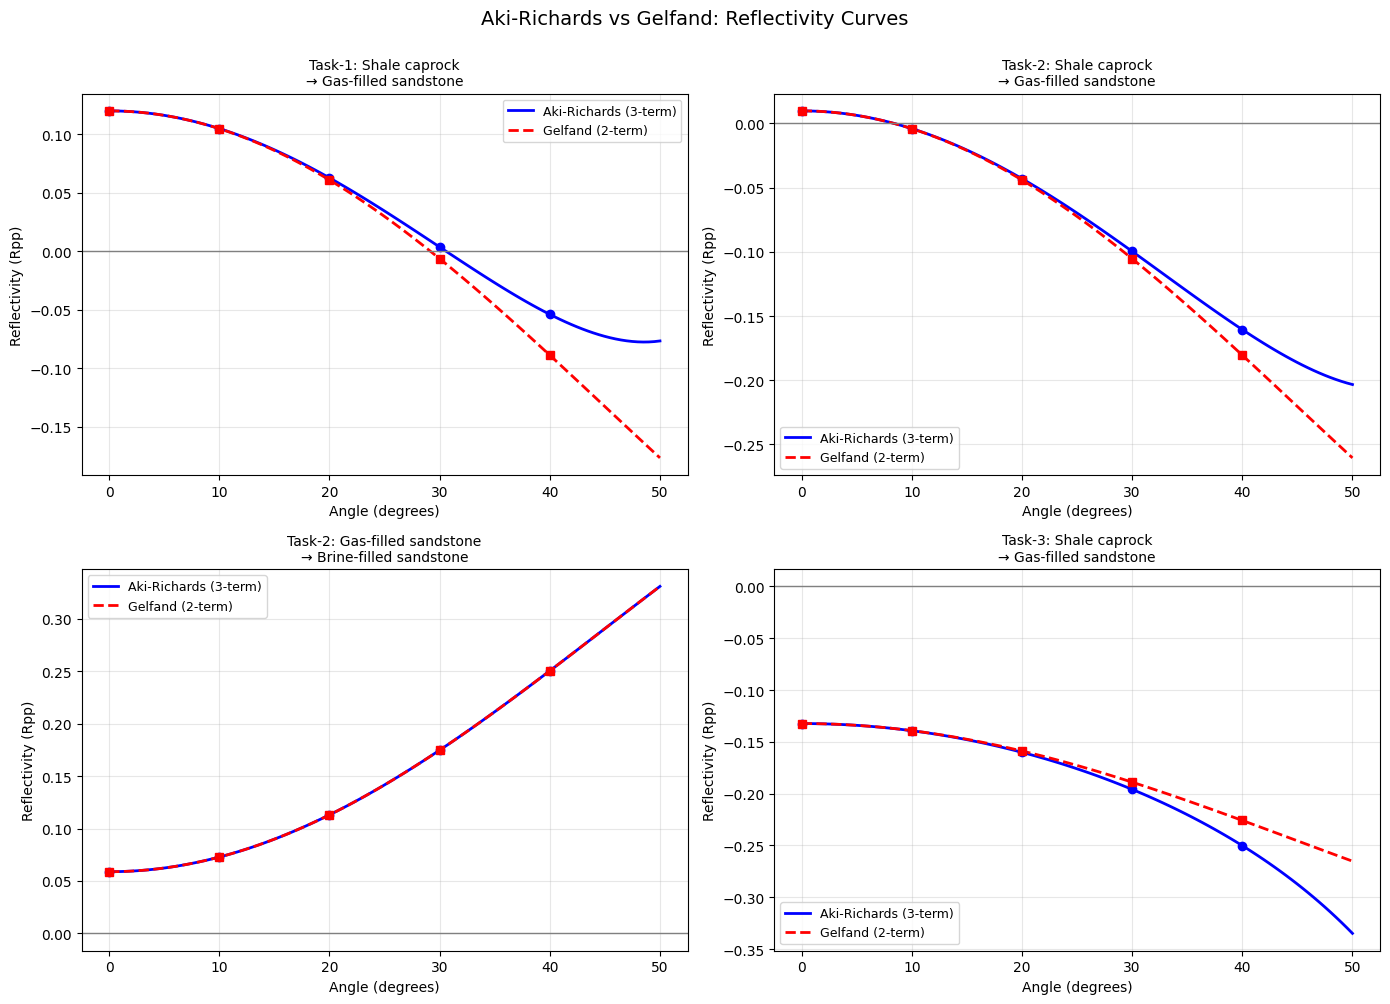


Difference between Aki-Richards and Gelfand at various angles:

Task-1: Shale caprock → Gas-filled sandstone
   Angle   Aki-Richards        Gelfand     Difference       % Diff
       0°       0.120000       0.120000       0.000000        0.00%
      10°       0.104861       0.104749       0.000113        0.11%
      20°       0.062695       0.060835       0.001860        2.97%
      30°       0.003556      -0.006444       0.010000      281.25%
      40°      -0.054066      -0.088975       0.034909      -64.57%
      45°      -0.072889      -0.132889       0.060000      -82.32%
      50°      -0.076788      -0.176803       0.100014     -130.25%

Task-2: Shale caprock → Gas-filled sandstone
   Angle   Aki-Richards        Gelfand     Difference       % Diff
       0°       0.009687       0.009687       0.000000        0.00%
      10°      -0.004129      -0.004193       0.000064       -1.56%
      20°      -0.043099      -0.044161       0.001062       -2.46%
      30°      -0.099685      

In [4]:
# Demonstrate difference between Aki-Richards and Gelfand at various angles
# Plot Rpp vs angle for selected interfaces

# Select a few representative interfaces for plotting
selected_indices = [0, 3, 4, 6]  # Different lithology transitions
angle_range = np.linspace(0, 50, 100)  # 0 to 50 degrees

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(selected_indices):
    ax = axes[i]
    
    # Get rock properties for this interface
    vp1 = df.loc[idx, "Vp_m_s"]
    vp2 = df.loc[idx, "Vp_m_s_next"]
    vs1 = df.loc[idx, "Vs_m_s"]
    vs2 = df.loc[idx, "Vs_m_s_next"]
    rho1 = df.loc[idx, "Density_g_cc"]
    rho2 = df.loc[idx, "Density_g_cc_next"]
    
    # Compute reflectivity curves
    rpp_aki = [aki_richards(ang, vp1, vp2, vs1, vs2, rho1, rho2) for ang in angle_range]
    rpp_gelfand = [gelfand(ang, vp1, vp2, vs1, vs2, rho1, rho2) for ang in angle_range]
    
    # Plot both curves
    ax.plot(angle_range, rpp_aki, 'b-', linewidth=2, label='Aki-Richards (3-term)')
    ax.plot(angle_range, rpp_gelfand, 'r--', linewidth=2, label='Gelfand (2-term)')
    
    # Mark the angles we computed
    for ang_deg in [0, 10, 20, 30, 40]:
        aki_val = aki_richards(ang_deg, vp1, vp2, vs1, vs2, rho1, rho2)
        gel_val = gelfand(ang_deg, vp1, vp2, vs1, vs2, rho1, rho2)
        ax.plot(ang_deg, aki_val, 'bo', markersize=6)
        ax.plot(ang_deg, gel_val, 'rs', markersize=6)
    
    interface_name = f"{df.loc[idx, 'Rock_Properties']}\n→ {df.loc[idx, 'Rock_Properties_next']}"
    ax.set_title(f"{df.loc[idx, 'Task']}: {interface_name}", fontsize=10)
    ax.set_xlabel("Angle (degrees)")
    ax.set_ylabel("Reflectivity (Rpp)")
    ax.grid(alpha=0.3)
    ax.axhline(0, color='gray', lw=1)
    ax.legend(fontsize=9)

plt.suptitle("Aki-Richards vs Gelfand: Reflectivity Curves", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Show numerical differences at key angles
print("\nDifference between Aki-Richards and Gelfand at various angles:")
print("="*80)
for idx in selected_indices:
    vp1 = df.loc[idx, "Vp_m_s"]
    vp2 = df.loc[idx, "Vp_m_s_next"]
    vs1 = df.loc[idx, "Vs_m_s"]
    vs2 = df.loc[idx, "Vs_m_s_next"]
    rho1 = df.loc[idx, "Density_g_cc"]
    rho2 = df.loc[idx, "Density_g_cc_next"]
    
    interface = f"{df.loc[idx, 'Rock_Properties']} → {df.loc[idx, 'Rock_Properties_next']}"
    print(f"\n{df.loc[idx, 'Task']}: {interface}")
    print(f"{'Angle':>8} {'Aki-Richards':>14} {'Gelfand':>14} {'Difference':>14} {'% Diff':>12}")
    
    for ang_deg in [0, 10, 20, 30, 40, 45, 50]:
        aki_val = aki_richards(ang_deg, vp1, vp2, vs1, vs2, rho1, rho2)
        gel_val = gelfand(ang_deg, vp1, vp2, vs1, vs2, rho1, rho2)
        diff = aki_val - gel_val
        pct_diff = 100 * diff / aki_val if aki_val != 0 else 0
        print(f"{ang_deg:8.0f}° {aki_val:14.6f} {gel_val:14.6f} {diff:14.6f} {pct_diff:11.2f}%")

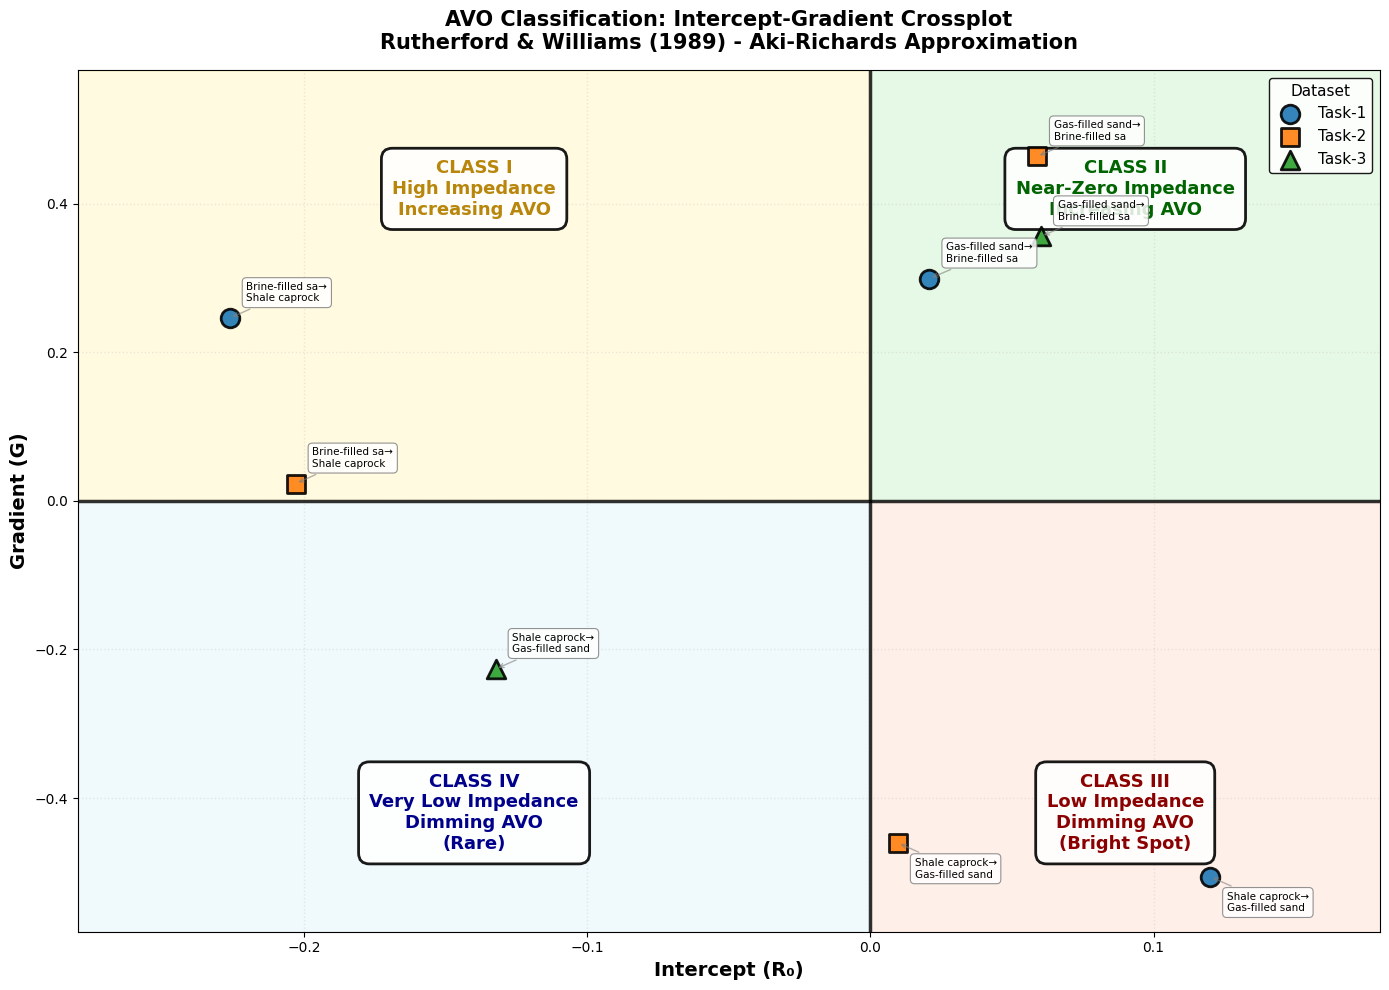


AVO CLASSIFICATION SUMMARY (Rutherford & Williams, 1989)
Interface                                                R₀        G      Class Description         
----------------------------------------------------------------------------------------------------
Shale caprock → Gas-filled sandstone                 0.1200  -0.5058  Class III Low Impedance (Bright)
Gas-filled sandstone → Brine-filled sandstone        0.0208   0.2993   Class II Near-Zero Contrast  
Brine-filled sandstone → Shale caprock              -0.2263   0.2461    Class I High Impedance      
Shale caprock → Gas-filled sandstone                 0.0097  -0.4603  Class III Low Impedance (Bright)
Gas-filled sandstone → Brine-filled sandstone        0.0588   0.4637   Class II Near-Zero Contrast  
Brine-filled sandstone → Shale caprock              -0.2030   0.0234    Class I High Impedance      
Shale caprock → Gas-filled sandstone                -0.1324  -0.2263   Class IV Very Low Impedance  
Gas-filled sandstone → Brine-

In [10]:
# Professional AVO Classification Plot based on Rutherford & Williams (1989)
# Standard industry classification for gradient-intercept crossplots

fig = plt.figure(figsize=(14, 10))

# Main intercept-gradient plot with proper AVO classification
ax_main = plt.subplot(1, 1, 1)

# Define AVO class regions with proper colors and labels
# Class I: R₀ < 0, G > 0 (High impedance contrast)
# Class II: R₀ > 0, G > 0 (Near zero impedance contrast, increasing with offset)
# Class IIp: R₀ slightly positive, G > 0
# Class III: R₀ > 0, G < 0 (Negative impedance contrast, classic bright spot)
# Class IV: R₀ < 0, G < 0 (Rare, very low impedance reservoir)

xlim = [-0.28, 0.18]
ylim = [-0.58, 0.58]

# Background quadrants with proper AVO classification colors
# Quadrant I: Class I (lower left - negative intercept, positive gradient)
ax_main.fill_between([xlim[0], 0], [0, 0], [ylim[1], ylim[1]], 
                      alpha=0.12, color='gold', zorder=0)

# Quadrant II: Class II (upper left - positive intercept, positive gradient)  
ax_main.fill_between([0, xlim[1]], [0, 0], [ylim[1], ylim[1]], 
                      alpha=0.12, color='limegreen', zorder=0)

# Quadrant III: Class III (upper right - positive intercept, negative gradient)
ax_main.fill_between([0, xlim[1]], [ylim[0], ylim[0]], [0, 0], 
                      alpha=0.12, color='coral', zorder=0)

# Quadrant IV: Class IV (lower right - negative intercept, negative gradient)
ax_main.fill_between([xlim[0], 0], [ylim[0], ylim[0]], [0, 0], 
                      alpha=0.12, color='skyblue', zorder=0)

# Add bold axes at origin
ax_main.axhline(0, color='black', lw=2.5, alpha=0.8, zorder=1)
ax_main.axvline(0, color='black', lw=2.5, alpha=0.8, zorder=1)

# Add class labels in each quadrant
label_fontsize = 13
label_weight = 'bold'
label_style = dict(fontsize=label_fontsize, fontweight=label_weight, 
                   bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                            edgecolor='black', linewidth=2, alpha=0.9))

ax_main.text(-0.14, 0.42, 'CLASS I\nHigh Impedance\nIncreasing AVO', 
             ha='center', va='center', **label_style, color='darkgoldenrod')

ax_main.text(0.09, 0.42, 'CLASS II\nNear-Zero Impedance\nIncreasing AVO', 
             ha='center', va='center', **label_style, color='darkgreen')

ax_main.text(0.09, -0.42, 'CLASS III\nLow Impedance\nDimming AVO\n(Bright Spot)', 
             ha='center', va='center', **label_style, color='darkred')

ax_main.text(-0.14, -0.42, 'CLASS IV\nVery Low Impedance\nDimming AVO\n(Rare)', 
             ha='center', va='center', **label_style, color='darkblue')

# Plot data points with distinct markers per task
colors_task = {'Task-1': '#1f77b4', 'Task-2': '#ff7f0e', 'Task-3': '#2ca02c'}
markers_task = {'Task-1': 'o', 'Task-2': 's', 'Task-3': '^'}

for task, grp in plot_df.groupby("Task"):
    ax_main.scatter(
        grp["AkiRichards_Intercept"], 
        grp["AkiRichards_Gradient"], 
        s=180, 
        marker=markers_task[task],
        color=colors_task[task],
        edgecolors='black',
        linewidths=2,
        label=task,
        alpha=0.9,
        zorder=5
    )

# Add interface labels with connecting lines
for _, row in plot_df.iterrows():
    r0 = row["AkiRichards_Intercept"]
    g = row["AkiRichards_Gradient"]
    
    # Shorten interface names for clarity
    interface = row["Interface"]
    interface_parts = interface.split(" → ")
    short_name = f"{interface_parts[0][:15]}→\n{interface_parts[1][:15]}"
    
    # Position labels to avoid overlap
    offset_x, offset_y = 12, 12
    if g < -0.3:  # Move labels for crowded negative gradient region
        offset_y = -25
    
    ax_main.annotate(
        short_name,
        (r0, g),
        textcoords="offset points",
        xytext=(offset_x, offset_y),
        fontsize=7.5,
        ha='left',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                 alpha=0.85, edgecolor='gray', linewidth=0.8),
        arrowprops=dict(arrowstyle='->', lw=1, color='gray', alpha=0.6),
        zorder=6
    )

# Styling
ax_main.set_xlabel("Intercept (R₀)", fontsize=14, fontweight='bold')
ax_main.set_ylabel("Gradient (G)", fontsize=14, fontweight='bold')
ax_main.set_title("AVO Classification: Intercept-Gradient Crossplot\n" +
                  "Rutherford & Williams (1989) - Aki-Richards Approximation", 
                  fontsize=15, fontweight='bold', pad=15)

ax_main.legend(loc='upper right', fontsize=11, framealpha=0.9, 
               edgecolor='black', title='Dataset', title_fontsize=11)

ax_main.grid(alpha=0.25, linestyle=':', linewidth=1, zorder=0)
ax_main.set_xlim(xlim)
ax_main.set_ylim(ylim)

# Add subtle background grid
ax_main.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Create detailed classification table
print("\n" + "="*100)
print("AVO CLASSIFICATION SUMMARY (Rutherford & Williams, 1989)")
print("="*100)
print(f"{'Interface':<50} {'R₀':>8} {'G':>8} {'Class':>10} {'Description':<20}")
print("-"*100)

class_descriptions = {
    "Class I": "High Impedance",
    "Class II": "Near-Zero Contrast",
    "Class III": "Low Impedance (Bright)",
    "Class IV": "Very Low Impedance"
}

for _, row in plot_df.iterrows():
    r0 = row["AkiRichards_Intercept"]
    g = row["AkiRichards_Gradient"]
    
    # Classify based on quadrants
    if r0 < 0 and g > 0:
        avo_class = "Class I"
    elif r0 > 0 and g > 0:
        avo_class = "Class II"
    elif r0 > 0 and g < 0:
        avo_class = "Class III"
    elif r0 < 0 and g < 0:
        avo_class = "Class IV"
    else:
        avo_class = "Boundary"
    
    desc = class_descriptions.get(avo_class, "N/A")
    print(f"{row['Interface']:<50} {r0:8.4f} {g:8.4f} {avo_class:>10} {desc:<20}")

print("\n" + "="*100)
print("KEY CHARACTERISTICS:")
print("  • Class I:   Impedance increases across interface, AVO response increases")
print("  • Class II:  Small impedance contrast, AVO response increases (gas sands)")
print("  • Class III: Impedance decreases, classic 'bright spot', AVO dims with angle")
print("  • Class IV:  Rare, very low impedance, AVO response decreases")
print("="*100)